In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df = pd.read_csv("/content/economic_index.csv")


In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [6]:
## Drop Unneccessary Columns
df.drop(columns = ["Unnamed: 0", "year", "month"], axis = 1, inplace=True)

In [7]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
##Check Null Values
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


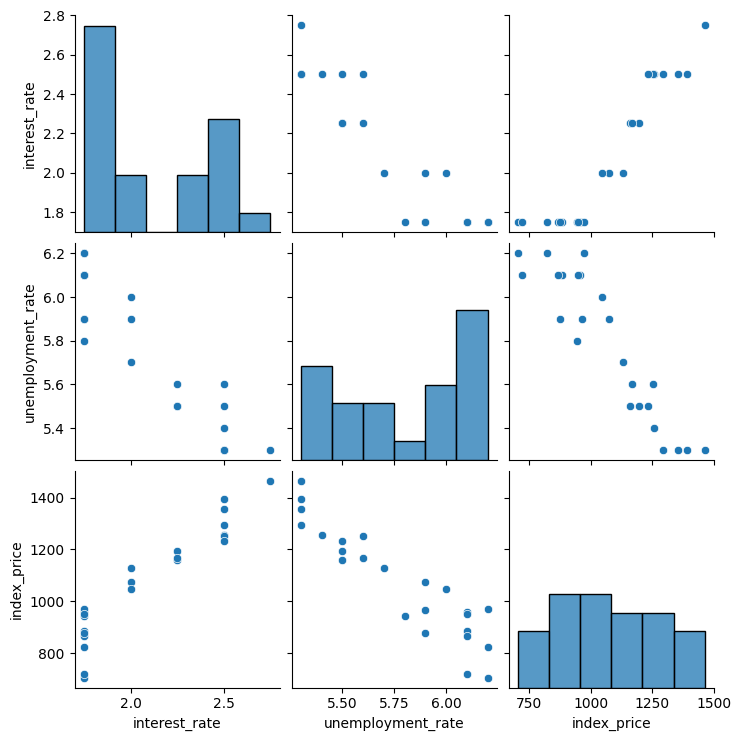

In [9]:
## Let's do some visualization
import seaborn as sns
sns.pairplot(df)

In [10]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment rate')

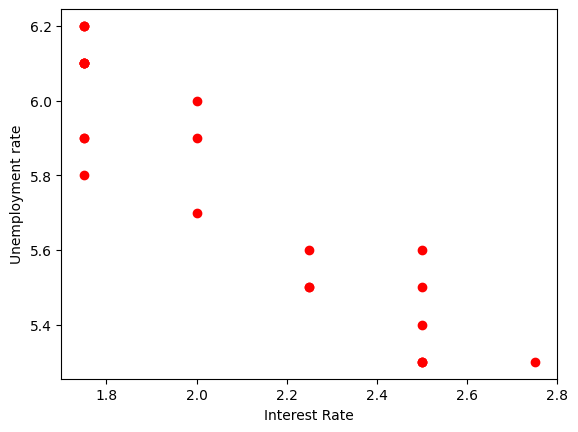

In [12]:
## Visualize the data points more closely
plt.scatter(df['interest_rate'], df['unemployment_rate'], color = 'r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment rate")

In [13]:
## Independent and Dependent features
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]


In [14]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [15]:
Y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [17]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 42)

In [23]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [26]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [28]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [29]:
regression.fit(X_train, Y_train)

LinearRegression()

In [36]:
## Cross Validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, Y_train, scoring = 'neg_mean_squared_error', cv = 3)

In [37]:
np.mean(validation_score)

-5914.828180162392

In [38]:
## Prediction
Y_pred = regression.predict(X_test)

In [39]:
Y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [40]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [41]:
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [43]:
from sklearn.metrics import r2_score
score = r2_score(Y_test, Y_pred)
print(score)

0.7591371539010257


ASSUMPTIONS


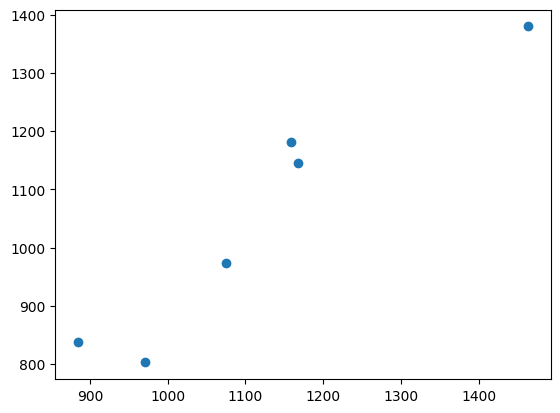

In [44]:
plt.scatter(Y_test,Y_pred)

In [45]:
residuals = Y_test - Y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


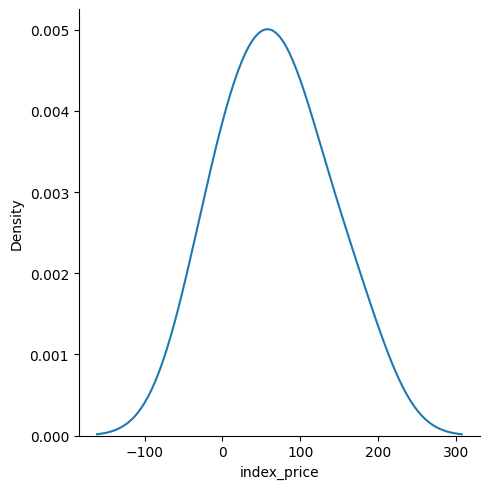

In [46]:
##Plot these Residuals
sns.displot(residuals, kind = 'kde')

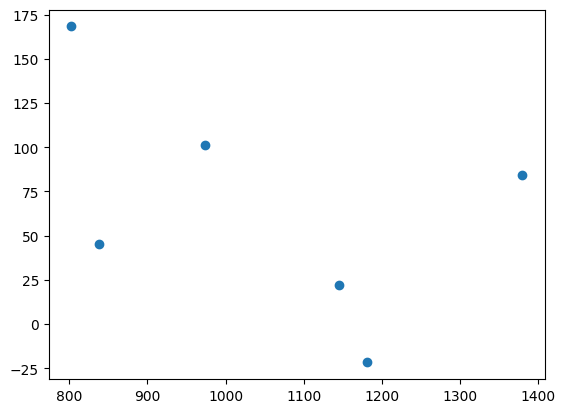

In [47]:
## Create a scatter plot with respect to prediction and Residuals
plt.scatter(Y_pred, residuals)

In [49]:
## OLS Linear Regression
import statsmodels.api as sm

In [50]:
model = sm.OLS(Y_train, X_train).fit()

In [51]:
prediction = model.predict(X_test)
print(prediction)

[ 127.30223686 -250.70164745  326.390126   -214.91844842  -79.59130481
   91.51903783]


In [52]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Tue, 22 Oct 2024   Prob (F-statistic):                       0.754
Time:                        07:18:27   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
